In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective, get_best_features, get_feature_bins_map
from etl_pipeline_local import get_over_25_table

sys.path.append("../..")
from strategies.strategies_utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARN)

load_dotenv()

True

In [2]:
# TODO: aggiungere early stopping

# 1. Load Data

In [5]:
# Bet setup
target_col = "over_25"
odds_col: str = "underOver_quote_currentO"

# Load data
df_loaded = get_over_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[df["underOver_quote_currentO"] >= 1.4]

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

# Feature acquisition
chance_features = list(df.filter(like="chance").columns)
goalNoGoal_features = list(df.filter(like="goalNoGoal").columns)
underOver_features = list(df.filter(like="underOver").columns)
evaluation_features = list(df.filter(like="evaluation").columns)
features_tot = chance_features + goalNoGoal_features + underOver_features + evaluation_features # goalNoGoal_features + underOver_features + evaluation_features

# 2. Feature Selection

In [6]:
# Define the feature selection raw search
objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 5, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
        {
            "n_startup_trials": 10, # 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
            "n_ei_candidates": 24, #128 # 24 default, problemi difficili: 64 o 128
        }
}

feature_rank = get_best_features(df=df_train, features=features_tot, objective_hyperparameters=objective_hyperparameters)

  9%|▉         | 12/131 [05:11<53:57, 27.21s/it] /home/maicolnicolini/code/bet-master-analytics/src/models/over_25/../feature_engineering.py:503: UserWarning: The distribution is specified by [1.2000000000000002, 15.400000000000002] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 15.4].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/over_25/../feature_engineering.py:509: UserWarning: The distribution is specified by [1.2000000000000002, 15.600000000000001] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 15.6].
  feat_max = trial.suggest_float(
 12%|█▏        | 16/131 [06:52<52:10, 27.22s/it]/home/maicolnicolini/code/bet-master-analytics/src/models/over_25/../feature_engineering.py:503: UserWarning: The distribution is specified by [2.4000000000000004, 12.8] and step=0.2, but the range is not divisible by `step`. It will be replaced wit

In [5]:
# Retrieve feature_bins_map draft
threshold = feature_rank['score'].quantile(0.75)
top_features = feature_rank[feature_rank['score'] >= threshold]['feature'].tolist()
feature_bins_map = get_feature_bins_map(df_train, top_features)
feature_bins_map

{'goalNoGoal_stats_avgGoalTakenAway': 0.2,
 'goalNoGoal_multigoal_m24Away': 5,
 'goalNoGoal_quote_realNG': 0.2,
 'underOver_quote_realU': 0.2,
 'goalNoGoal_multigoal_m13Away': 5,
 'goalNoGoal_quote_diffInitialCurrGG': 5,
 'goalNoGoal_stats_avgGoalAway': 0.2,
 'goalNoGoal_quote_diffRealCurrNG': 5,
 'underOver_chance_under35': 5,
 'underOver_chance_over35': 5,
 'goalNoGoal_comparison_flashback': 500,
 'goalNoGoal_quote_diffRealCurrGG': 5,
 'underOver_bookkeeping_actual': 0.2,
 'evaluation_valMetrica': None,
 'goalNoGoal_quote_currentNG': 0.2,
 'underOver_quote_diffInitialCurrO': 5,
 'goalNoGoal_quote_initialGG': 0.2,
 'goalNoGoal_comparison_affini': 500,
 'underOver_quote_diffInitialCurrU': 5,
 'underOver_quote_realO': 0.2,
 'goalNoGoal_chance_goalAway': 5,
 'underOver_quote_diffRealCurrO': 5}

## 2. Define Parameters

In [14]:
feature_rank.head(20)

,feature,score
0,goalNoGoal_stats_avgGoalTakenAway,-0.763013
1,goalNoGoal_multigoal_m24Away,-1.036313
2,goalNoGoal_quote_realNG,-1.198712
3,underOver_quote_realU,-1.220466
4,goalNoGoal_multigoal_m13Away,-1.221136
5,goalNoGoal_quote_diffInitialCurrGG,-1.248712
6,goalNoGoal_stats_avgGoalAway,-1.341486
7,goalNoGoal_quote_diffRealCurrNG,-1.392938
8,underOver_chance_under35,-1.458635
9,underOver_chance_over35,-1.458635


In [19]:
# Define features and relative step

feature_bins_map = {
 'goalNoGoal_stats_avgGoalTakenAway': 0.2,
 'goalNoGoal_multigoal_m24Away': 5,
 'goalNoGoal_quote_realNG': 0.2,
#  'underOver_quote_realU': 0.2,
#  'goalNoGoal_multigoal_m13Away': 5,
#  'goalNoGoal_quote_diffInitialCurrGG': 5,
#  'goalNoGoal_stats_avgGoalAway': 0.2,
#  'goalNoGoal_quote_diffRealCurrNG': 5,
#  'underOver_chance_over35': 5,
#  'goalNoGoal_comparison_flashback': 500,
#  'goalNoGoal_quote_diffRealCurrGG': 5,
#  'underOver_bookkeeping_actual': 0.2,
#  'evaluation_valMetrica': None,
#  'goalNoGoal_quote_currentNG': 0.2,
#  'underOver_quote_diffInitialCurrO': 5,
#  'goalNoGoal_quote_initialGG': 0.2,
#  'goalNoGoal_comparison_affini': 500,
#  'underOver_quote_diffInitialCurrU': 5,
#  'underOver_quote_realO': 0.2,
#  'goalNoGoal_chance_goalAway': 5,
#  'underOver_quote_diffRealCurrO': 5
 }
 

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 1, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: goalNoGoal_stats_avgGoalTakenAway
Search space: [0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 5. ]


Feature: goalNoGoal_multigoal_m24Away
Search space: <IntegerArray>
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90]
Length: 19, dtype: Int64


Feature: goalNoGoal_quote_realNG
Search space: [1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6 3.8 4.  4.2 4.4 4.6
 4.8 5.  5.4 5.6 5.8 7. ]




## 3. Optimize

In [20]:
optuna.logging.set_verbosity(optuna.logging.INFO)

# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

[I 2026-04-14 17:35:09,009] A new study created in memory with name: no-name-b4145381-74ef-4c18-b52b-41ac8e99fbe1
[I 2026-04-14 17:35:09,023] Trial 0 pruned. 
[I 2026-04-14 17:35:09,026] Trial 1 pruned. 
[I 2026-04-14 17:35:09,029] Trial 2 pruned. 
/home/maicolnicolini/code/bet-master-analytics/src/models/over_25/../feature_engineering.py:321: UserWarning: The distribution is specified by [1.2000000000000002, 6.8] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/over_25/../feature_engineering.py:327: UserWarning: The distribution is specified by [1.2000000000000002, 7.0] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.8].
  feat_max = trial.suggest_float(
[I 2026-04-14 17:35:09,047] Trial 3 finished with value: -1000000000.0 and parameters: {'goalNoGoal_stats_avgGoalT

[FrozenTrial(number=230, state=<TrialState.COMPLETE: 1>, values=[-0.7009084370277353], datetime_start=datetime.datetime(2026, 4, 14, 17, 35, 13, 744179), datetime_complete=datetime.datetime(2026, 4, 14, 17, 35, 13, 771616), params={'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': True, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 2.2, 'goalNoGoal_stats_avgGoalTakenAway_max': 4.0, 'goalNoGoal_multigoal_m24Away_use_min': False, 'goalNoGoal_multigoal_m24Away_use_max': True, 'use_goalNoGoal_multigoal_m24Away': True, 'goalNoGoal_multigoal_m24Away_min': 5, 'goalNoGoal_multigoal_m24Away_max': 15, 'goalNoGoal_quote_realNG_use_min': True, 'goalNoGoal_quote_realNG_use_max': True, 'use_goalNoGoal_quote_realNG': False, 'goalNoGoal_quote_realNG_min': 4.800000000000001, 'goalNoGoal_quote_realNG_max': 6.4}, user_attrs={'params_dict': {'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTa

## 4. Evaluate

In [21]:
# Create the test binned dataframe
return_threshold = -3.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 1
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 2
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 3
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 4
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 5
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 6
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 7
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 8
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353


Trial no. 9
Min return -2.0
Max return 4.300000000000001
Score -0.7009084370277353




Mean Train ROI: 0.18896226415094344
Train Accuracy: 0.6 (68/106)
Mean Test ROI: 0.5288235294117647
Test Accuracy: 0.6 (11/17)


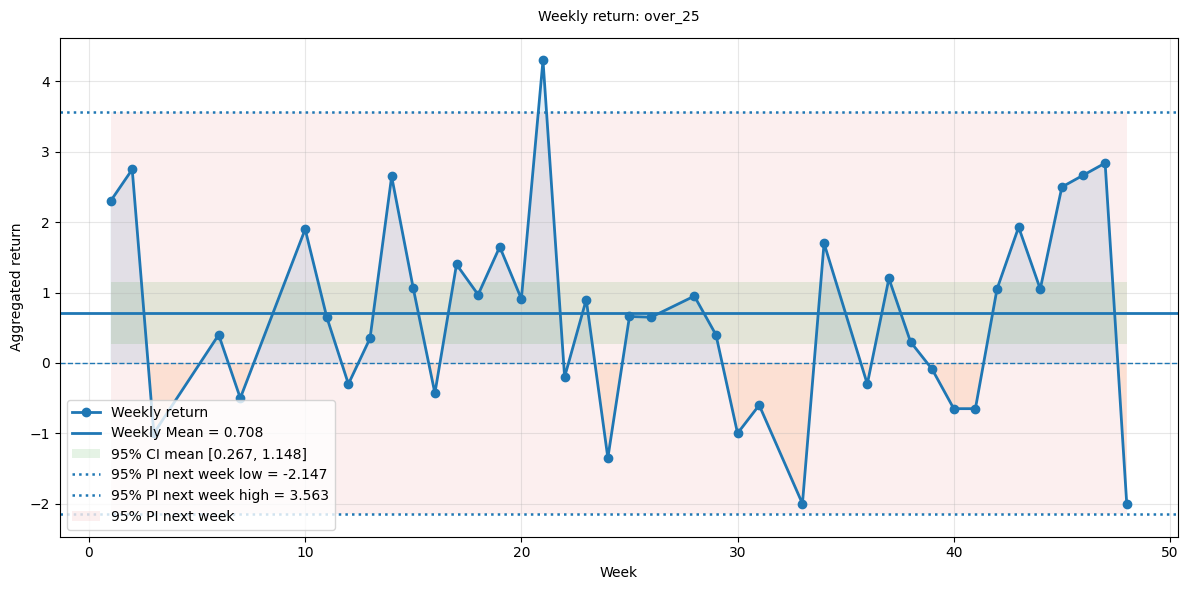

In [22]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [73]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 34/49 (0.69)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_15,0.73,0.97,2.84,2.93,139,0.84


## 5. Save best Trials

In [74]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

Aggiunti: 1
Totale trial archiviati: 3
Best assoluto: -0.13275429337616318 {'underOver_quote_diffRealCurrU_use_min': False, 'underOver_quote_diffRealCurrU_use_max': True, 'use_underOver_quote_diffRealCurrU': False, 'underOver_quote_diffRealCurrU_min': 85, 'underOver_quote_diffRealCurrU_max': 300, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': False, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.4000000000000001, 'goalNoGoal_stats_avgGoalTakenAway_max': 4.2, 'goalNoGoal_flashback_m24_include_missing': False, 'goalNoGoal_flashback_m24_use_min': True, 'goalNoGoal_flashback_m24_use_max': True, 'use_goalNoGoal_flashback_m24': True, 'goalNoGoal_flashback_m24_min': 62, 'goalNoGoal_flashback_m24_max': 63, 'underOver_chance_over25_use_min': False, 'underOver_chance_over25_use_max': True, 'use_underOver_chance_over25': True, 'underOver_chance_over25_min': 25, 'underOver_chance_over25_max': 60, 'underOver

/tmp/ipykernel_60717/4034433927.py:14: UserWarning: The distribution is specified by [1.2000000000000002, 6.2] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.0].
  existing = {trial_key(t) for t in study.trials if t.value is not None}
/tmp/ipykernel_60717/4034433927.py:14: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  existing = {trial_key(t) for t in study.trials if t.value is not None}
